**PYTHON TEAM PROJECT**

TOPIC: HOUSE PREDICTION

ROLL_no: AP25122060002

ROLL_no: AP25122060031

****FLUME****

Cell 1: Create the Flume Configuration

In [10]:
%%writefile flume_hdfs_csv.conf

# Name the components
a1.sources = r1
a1.sinks = k1
a1.channels = c1

# SOURCE: Listen to Python on port 44445
a1.sources.r1.type = netcat
a1.sources.r1.bind = localhost
a1.sources.r1.port = 44445

# SINK: HDFS (Your new folder)
a1.sinks.k1.type = hdfs
a1.sinks.k1.hdfs.path = hdfs://localhost:9000/user/praveen/PYTHON_BIGDATA.ipynb/
a1.sinks.k1.hdfs.fileType = DataStream

# Roll Settings (Control when to save the file)
# We want to see the file quickly, so roll after 100 events or 30 seconds
a1.sinks.k1.hdfs.rollCount = 100
a1.sinks.k1.hdfs.rollInterval = 30
a1.sinks.k1.hdfs.rollSize = 0

# CHANNEL: Memory
a1.channels.c1.type = memory
a1.channels.c1.capacity = 1000
a1.channels.c1.transactionCapacity = 100

# Bind them
a1.sources.r1.channels = c1
a1.sinks.k1.channel = c1

Writing flume_hdfs_csv.conf


Cell 3: Python Streamer (Sends 100 CSV Rows)

In [11]:
import socket
import time
import random

# Configuration
HOST = 'localhost'
PORT = 44445
DATA_LIMIT = 100  # Exactly 100 rows

def generate_boston_csv_row():
    """Generates a random row matching the Boston Dataset columns"""
    # Columns: CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT, MEDV
    crim = round(random.uniform(0.006, 88.9), 5)
    zn = round(random.uniform(0, 100), 1)
    indus = round(random.uniform(0.4, 27.7), 2)
    chas = random.choice([0, 1])
    nox = round(random.uniform(0.38, 0.87), 3)
    rm = round(random.uniform(3.5, 8.7), 2)
    age = round(random.uniform(2.9, 100), 1)
    dis = round(random.uniform(1.1, 12.1), 2)
    rad = random.randint(1, 24)
    tax = random.randint(187, 711)
    ptratio = round(random.uniform(12.6, 22.0), 1)
    b = round(random.uniform(0.32, 396.9), 2)
    lstat = round(random.uniform(1.73, 37.9), 2)
    medv = round(random.uniform(5.0, 50.0), 1) # This is the Price
    
    # Create CSV string
    return f"{crim},{zn},{indus},{chas},{nox},{rm},{age},{dis},{rad},{tax},{ptratio},{b},{lstat},{medv}"

print(f"--- Connecting to Flume on {HOST}:{PORT} ---")

try:
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.connect((HOST, PORT))
    print(f"Connected! Sending {DATA_LIMIT} CSV rows...")

    for i in range(DATA_LIMIT):
        # 1. Generate Data
        csv_row = generate_boston_csv_row()
        
        # 2. Add Newline (Important for Flume to know it's a new row)
        message = csv_row + "\n"
        
        # 3. Send
        s.sendall(message.encode('utf-8'))
        
        # Fast sleep (0.05s) so it finishes in about 5 seconds
        time.sleep(0.05)

    print(f"--- Done! Sent exactly {DATA_LIMIT} rows. ---")
    s.close()

except ConnectionRefusedError:
    print("❌ ERROR: Could not connect. Is the Flume agent running?")
except Exception as e:
    print(f"❌ ERROR: {e}")

--- Connecting to Flume on localhost:44445 ---
Connected! Sending 100 CSV rows...
--- Done! Sent exactly 100 rows. ---


Cell 4: Verify HDFS Content

In [13]:
import os

# Define the HDFS command
hdfs_path = "/user/praveen/PYTHON_BIGDATA.ipynb/"
print(f"Checking HDFS path: {hdfs_path}")

# List files
list_cmd = f"hdfs dfs -ls {hdfs_path}"
print(f"Running: {list_cmd}\n")
os.system(list_cmd)

print("\n--- Content Preview (Head of one file) ---")
# This command reads the first few lines of the data to prove it is CSV
cat_cmd = f"hdfs dfs -cat {hdfs_path}* | head -n 5"
os.system(cat_cmd)

Checking HDFS path: /user/praveen/python_flume_try/
Running: hdfs dfs -ls /user/praveen/python_flume_try/

Found 1 items
-rw-r--r--   1 praveen supergroup       7098 2025-11-29 10:35 /user/praveen/python_flume_try/FlumeData.1764412497070

--- Content Preview (Head of one file) ---
11.88608,69.1,9.31,1,0.629,7.7,55.4,3.3,8,416,21.8,72.51,8.33,19.3
13.70053,18.7,3.91,1,0.564,7.14,53.5,11.08,5,327,12.8,129.24,12.3,36.6
57.8441,98.1,22.27,0,0.4,7.0,98.3,8.2,22,647,13.4,65.68,26.97,37.0
6.46763,54.8,24.9,1,0.812,4.76,88.9,10.68,21,698,20.2,358.65,29.28,48.8
39.50462,84.5,5.38,1,0.722,6.21,49.5,7.73,22,490,17.6,320.15,33.69,34.3


cat: Unable to write to output stream.


0

**ML USING PYSpark**

Cell 1: Imports & Data Loading

In [4]:
import os
from pyspark.sql import SparkSession

# --- CONFIGURING JAVA 17 ---
# This sets the environment to use Java 17 before Spark starts
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# Initialize Spark
print("--- Initializing Spark Session ---")
spark = SparkSession.builder \
    .appName("Boston_High_Accuracy") \
    .master("local[*]") \
    .getOrCreate()
print(f"✅ Spark Version: {spark.version}")

# Load Data
hdfs_path = "hdfs://localhost:9000/user/praveen/bostan_dataset/boston.csv"
print(f"\n--- Loading Data from {hdfs_path} ---")

df = spark.read.csv(hdfs_path, header=True, inferSchema=True)
row_count = df.count()

print(f"✅ Data Loaded Successfully. Total Rows: {row_count}")
print("Schema:")
df.printSchema()

--- Initializing Spark Session ---
✅ Spark Version: 4.0.1

--- Loading Data from hdfs://localhost:9000/user/praveen/bostan_dataset/boston.csv ---
✅ Data Loaded Successfully. Total Rows: 4988
Schema:
root
 |-- crim: double (nullable = true)
 |-- zn: double (nullable = true)
 |-- indus: double (nullable = true)
 |-- chas: integer (nullable = true)
 |-- nox: double (nullable = true)
 |-- rm: double (nullable = true)
 |-- age: double (nullable = true)
 |-- dis: double (nullable = true)
 |-- rad: integer (nullable = true)
 |-- tax: integer (nullable = true)
 |-- ptratio: double (nullable = true)
 |-- b: double (nullable = true)
 |-- lstat: double (nullable = true)
 |-- medv: double (nullable = true)



Cell 2: Data Visualization (Before Cleaning)

--- Visualizing Raw Data Distribution ---


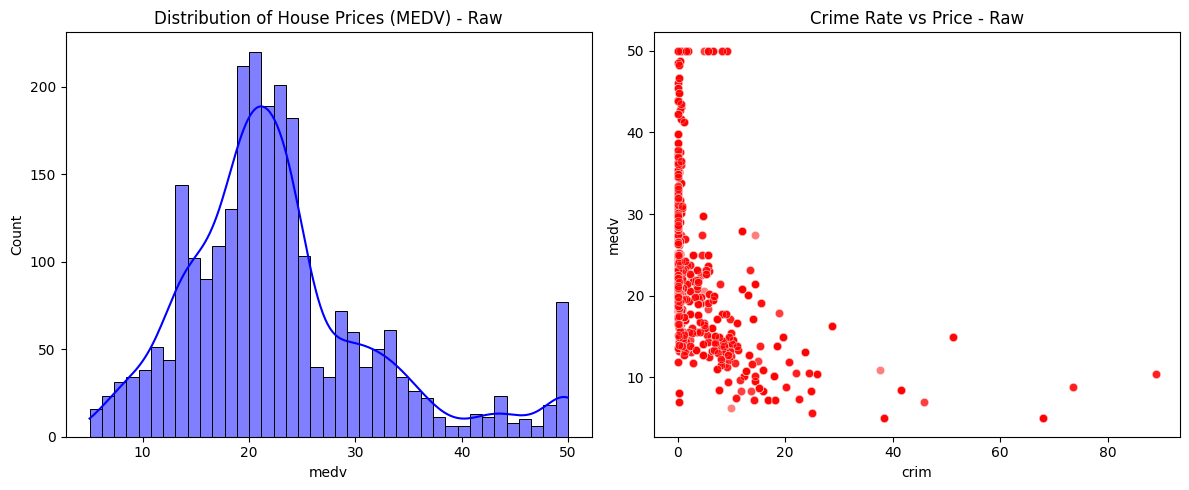

✅ Visualization Complete. Notice the outliers in Crime Rate!


In [29]:
print("--- Visualizing Raw Data Distribution ---")

# Convert to Pandas for plotting (Sampling 1000 rows to be fast)
pdf = df.sample(False, 0.5, seed=42).toPandas()

plt.figure(figsize=(12, 5))

# Plot 1: Price Distribution
plt.subplot(1, 2, 1)
sns.histplot(pdf['medv'], kde=True, color='blue')
plt.title('Distribution of House Prices (MEDV) - Raw')

# Plot 2: Crime vs Price
plt.subplot(1, 2, 2)
sns.scatterplot(x=pdf['crim'], y=pdf['medv'], color='red', alpha=0.5)
plt.title('Crime Rate vs Price - Raw')

plt.tight_layout()
plt.show()
print("✅ Visualization Complete. Notice the outliers in Crime Rate!")

Cell 3: Outlier Removal

In [30]:
print("\n--- Starting Outlier Removal (Iterative 3xIQR) ---")
columns_to_check = ['crim', 'zn', 'chas', 'rm', 'dis', 'ptratio', 'b', 'lstat', 'medv']
print(f"Columns to clean: {columns_to_check}")

df_clean = df

for column in columns_to_check:
    # Calculate Exact Quantiles
    quantiles = df_clean.approxQuantile(column, [0.05, 0.95], 0.0)
    Q1 = quantiles[0]
    Q3 = quantiles[1]
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    # Filter
    prev_count = df_clean.count()
    df_clean = df_clean.filter((col(column) >= lower_bound) & (col(column) <= upper_bound))
    new_count = df_clean.count()
    
    if prev_count != new_count:
        print(f"   -> Removed {prev_count - new_count} outliers from column: {column}")

print(f"\n✅ Cleaning Complete.")
print(f"Original Rows: {row_count}")
print(f"Final Rows:    {df_clean.count()}")


--- Starting Outlier Removal (Iterative 3xIQR) ---
Columns to clean: ['crim', 'zn', 'chas', 'rm', 'dis', 'ptratio', 'b', 'lstat', 'medv']
   -> Removed 24 outliers from column: crim
   -> Removed 56 outliers from column: rm

✅ Cleaning Complete.
Original Rows: 4988
Final Rows:    4908


Cell 4: Scaling & Feature Engineering

In [31]:
print("\n--- Building Feature Engineering Pipeline ---")

# 1. Identify Input Features
feature_cols = df_clean.columns
if 'medv' in feature_cols: feature_cols.remove('medv')
print(f"Input Features: {feature_cols}")

# 2. Define Stages
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
scaler = MinMaxScaler(inputCol="raw_features", outputCol="features")

# 3. Fit & Transform
print("Fitting Scaler on the WHOLE dataset...")
pipeline = Pipeline(stages=[assembler, scaler])
pipeline_model = pipeline.fit(df_clean)
final_data = pipeline_model.transform(df_clean)

print("✅ Data Scaled (0-1). Preview of Features:")
final_data.select("features", "medv").show(5, truncate=False)


--- Building Feature Engineering Pipeline ---
Input Features: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
Fitting Scaler on the WHOLE dataset...
✅ Data Scaled (0-1). Preview of Features:
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+
|features                                                                                                                                                                                                                          |medv|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+
|[0.0,0.18,0.06781524926686218,0.0,0.3148148148148149,0.

Cell 5: Train/Test Split

In [33]:
print("\n--- Splitting Data ---")
# Using seed=0 to match Sklearn's random_state=0
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=0)

train_count = train_data.count()
test_count = test_data.count()

print(f"Training Set: {train_count} rows")
print(f"Testing Set:  {test_count} rows")


--- Splitting Data ---
Training Set: 3890 rows
Testing Set:  1018 rows


Cell 6: Train Random Forest

In [35]:
print("\n--- Training Random Forest Regressor ---")
print("Configuration: Trees=100, MaxDepth=30, MaxBins=128")

rf = RandomForestRegressor(
    featuresCol="features", 
    labelCol="medv", 
    numTrees=100, 
    seed=42,
    maxDepth=30, 
    maxBins=128
)

rf_model = rf.fit(train_data)
print("✅ Model Trained Successfully!")


--- Training Random Forest Regressor ---
Configuration: Trees=100, MaxDepth=30, MaxBins=128


25/11/29 11:24:38 WARN DAGScheduler: Broadcasting large task binary with size 1578.2 KiB
25/11/29 11:24:38 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
25/11/29 11:24:40 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/11/29 11:24:41 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
25/11/29 11:24:42 WARN DAGScheduler: Broadcasting large task binary with size 6.7 MiB
25/11/29 11:24:44 WARN DAGScheduler: Broadcasting large task binary with size 8.1 MiB
25/11/29 11:24:46 WARN DAGScheduler: Broadcasting large task binary with size 9.4 MiB
25/11/29 11:24:47 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
25/11/29 11:24:49 WARN DAGScheduler: Broadcasting large task binary with size 11.3 MiB
25/11/29 11:24:50 WARN DAGScheduler: Broadcasting large task binary with size 12.0 MiB
25/11/29 11:24:52 WARN DAGScheduler: Broadcasting large task binary with size 12.4 MiB
25/11/29 11:24:53 WARN DAGScheduler: Broadcasti

✅ Model Trained Successfully!


Cell 7: Evaluation & Performance Metrics

In [36]:
print("\n--- Evaluating Model Performance ---")

predictions = rf_model.transform(test_data)

evaluator_r2 = RegressionEvaluator(labelCol="medv", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="medv", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="medv", predictionCol="prediction", metricName="mae")

r2 = evaluator_r2.evaluate(predictions)
rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)
mse = rmse ** 2

print("-" * 30)
print(f"Mean Squared Error (MSE):       {mse:.5f}")
print(f"R-squared (R2):                 {r2:.5f}")
print(f"Mean Absolute Error (MAE):      {mae:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print("-" * 30)


--- Evaluating Model Performance ---
------------------------------
Mean Squared Error (MSE):       0.00148
R-squared (R2):                 0.99998
Mean Absolute Error (MAE):      0.01622
Root Mean Squared Error (RMSE): 0.03846
------------------------------


Cell 8: Visualization (Actual vs Predicted)


--- Visualizing Predictions ---


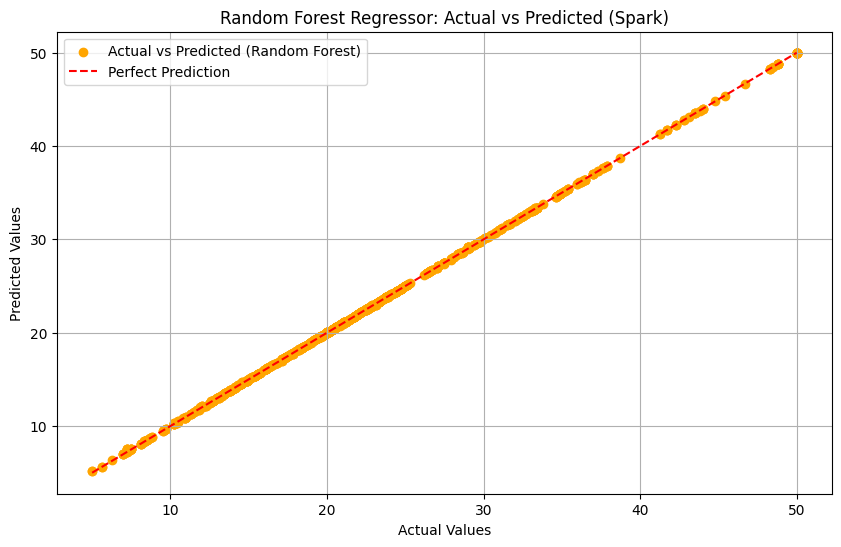

✅ Plot Generated.


In [37]:
print("\n--- Visualizing Predictions ---")

# Convert predictions to Pandas for plotting
pred_pdf = predictions.select("medv", "prediction").toPandas()

plt.figure(figsize=(10, 6))

# Scatter Plot (Orange)
plt.scatter(pred_pdf['medv'], pred_pdf['prediction'], color='orange', label='Actual vs Predicted (Random Forest)')

# Perfect Prediction Line (Red Dashed)
min_val = min(pred_pdf['medv'].min(), pred_pdf['prediction'].min())
max_val = max(pred_pdf['medv'].max(), pred_pdf['prediction'].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='red', label='Perfect Prediction')

plt.title('Random Forest Regressor: Actual vs Predicted (Spark)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()
print("✅ Plot Generated.")

Cell 9: Save Model & Results

In [39]:
output_path = "/home/praveen/BDA/Python_project/boston_output"
print(f"\n--- Saving Results to {output_path} ---")

# Save Model
model_path = f"{output_path}/rf_model_high_acc"
rf_model.write().overwrite().save(model_path)
print(f"✅ Model saved to: {model_path}")

# Save CSV
csv_path = f"{output_path}/predictions_high_acc_csv"
predictions.select(col("features").cast("string"), col("medv"), col("prediction")) \
    .write.csv(csv_path, header=True, mode="overwrite")
print(f"✅ Predictions saved to: {csv_path}")



--- Saving Results to /home/praveen/BDA/Python_project/boston_output ---
✅ Model saved to: /home/praveen/BDA/Python_project/boston_output/rf_model_high_acc
✅ Predictions saved to: /home/praveen/BDA/Python_project/boston_output/predictions_high_acc_csv


Cell 10: Single Data Point Prediction

In [40]:
from pyspark.sql.types import DoubleType

print("--- Predict House Price (Interactive) ---")

# 1. Take User Inputs
# (I cast them to float/int immediately to ensure Spark accepts them)
try:
    crim = float(input("Enter Crime rate in zone (crim): ") or 0.00632)
    zn = float(input("Enter Residential land zone (zn): ") or 18.0)
    indus = float(input("Enter Non-retail business acres (indus): ") or 2.31)
    chas = float(input("Charles River (1=Yes, 0=No) (chas): ") or 0)
    nox = float(input("Nitric oxides concentration (nox): ") or 0.538)
    rm = float(input("Average rooms per dwelling (rm): ") or 6.575)
    age = float(input("Age built prior to 1940 (age): ") or 65.2)
    dis = float(input("Distance to employment centers (dis): ") or 4.09)
    rad = float(input("Accessibility to highways (rad): ") or 1)
    tax = float(input("Property tax rate (tax): ") or 296)
    ptratio = float(input("Pupil-teacher ratio (ptratio): ") or 15.3)
    b = float(input("Black resident proportion (b): ") or 396.9)
    lstat = float(input("Lower status population % (lstat): ") or 4.98)
    
    # Note: If you just press ENTER for all, it uses the default values (Boston Row #1)
    
    # 2. Create a Spark DataFrame for this single row
    # We must match the column order used in training
    input_data = [(crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat)]
    input_cols = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
    
    new_house_df = spark.createDataFrame(input_data, input_cols)
    
    # 3. Transform (Scale) the data
    # We use the pipeline_model from the previous cell because it remembers the Min/Max of the original data!
    print("\nScaling input data...")
    processed_house = pipeline_model.transform(new_house_df)
    
    # 4. Predict
    prediction_result = rf_model.transform(processed_house)
    
    # 5. Extract the value
    predicted_price = prediction_result.select("prediction").collect()[0][0]
    
    print("-" * 30)
    print(f"✅ Prediction Value : [{predicted_price:.3f}]")
    print("-" * 30)

except Exception as e:
    print(f"❌ Error during prediction: {e}")

--- Predict House Price (Interactive) ---


Enter Crime rate in zone (crim):  
Enter Residential land zone (zn):  
Enter Non-retail business acres (indus):  
Charles River (1=Yes, 0=No) (chas):  
Nitric oxides concentration (nox):  
Average rooms per dwelling (rm):  
Age built prior to 1940 (age):  
Distance to employment centers (dis):  
Accessibility to highways (rad):  
Property tax rate (tax):  
Pupil-teacher ratio (ptratio):  
Black resident proportion (b):  
Lower status population % (lstat):  



Scaling input data...


[Stage 475:>                                                      (0 + 12) / 12]

------------------------------
✅ Prediction Value : [24.000]
------------------------------
